In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [53]:
df = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_cleaned.csv')
#df = df.drop(['index'], axis=1)

df.head()
df['fire_size'].describe()

count     37208.000000
mean       2211.284929
std       14890.174705
min           0.510000
25%           1.100000
50%           4.000000
75%          20.000000
max      538049.000000
Name: fire_size, dtype: float64

In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37208 entries, 0 to 37207
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            37208 non-null  int64  
 1   fire_size        37208 non-null  float64
 2   fire_size_class  37208 non-null  object 
 3   latitude         37208 non-null  float64
 4   longitude        37208 non-null  float64
 5   discovery_month  37208 non-null  object 
 6   Vegetation       37208 non-null  int64  
 7   Temp_pre_30      37208 non-null  float64
 8   Temp_pre_15      37208 non-null  float64
 9   Temp_pre_7       37208 non-null  float64
 10  Wind_pre_30      37208 non-null  float64
 11  Wind_pre_15      37208 non-null  float64
 12  Wind_pre_7       37208 non-null  float64
 13  Hum_pre_30       37208 non-null  float64
 14  Hum_pre_15       37208 non-null  float64
 15  Hum_pre_7        37208 non-null  float64
 16  Prec_pre_30      37208 non-null  float64
 17  Prec_pre_15 

,index,fire_size,latitude,longitude,Vegetation,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,Hum_pre_7,Prec_pre_30,Prec_pre_15,Prec_pre_7,remoteness,catastrophic
count,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000
mean,20491.940443,2211.284929,36.475461,-95.643236,11.072646,15.751560,16.252676,16.611517,3.171764,3.160079,3.136735,60.973810,60.040488,58.948962,39.482359,17.723995,7.361304,0.243298,0.346216
std,11841.298864,14890.174705,6.813169,15.877186,5.556529,8.534825,8.417871,8.474401,1.177843,1.227829,1.313413,13.714828,14.182339,14.894387,134.725873,68.620599,37.778079,0.144646,0.475769
min,0.000000,0.510000,17.958364,-165.116700,0.000000,-16.078723,-37.000000,-48.200000,0.024922,0.017250,0.000000,5.625000,5.625000,5.625000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10251.750000,1.100000,32.377439,-103.445108,9.000000,9.127583,9.715080,10.037742,2.350902,2.299691,2.221819,55.237437,53.461904,50.968015,0.000000,0.000000,0.000000,0.140661,0.000000
50%,20458.500000,4.000000,34.699420,-93.185815,12.000000,15.555082,16.070776,16.600000,3.072371,3.053857,3.010513,64.213802,63.044628,61.650099,3.400000,0.000000,0.000000,0.210863,0.000000
75%,30726.250000,20.000000,39.783547,-83.550410,15.000000,23.115392,23.434649,23.793842,3.868383,3.877827,3.891667,70.334410,69.892706,69.469600,43.600000,15.125000,2.300000,0.291913,1.000000
max,41131.000000,538049.000000,69.047200,-65.417709,16.000000,41.677820,51.567797,55.000000,29.800000,29.800000,29.800000,96.000000,96.000000,100.000000,13560.800000,2527.000000,1638.000000,1.000000,1.000000


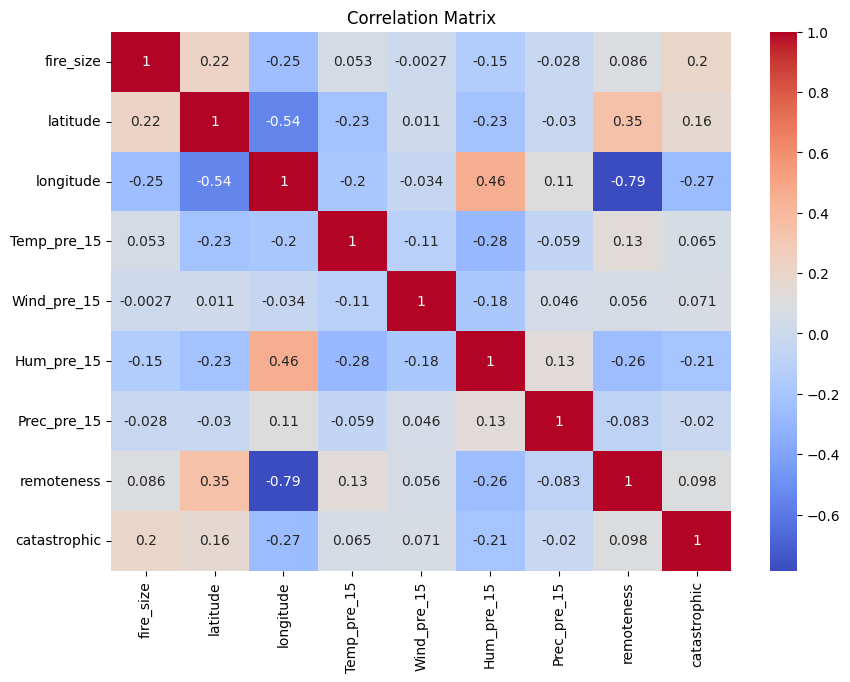

In [42]:

#excluding some of the colums
exclude_cols = ['index','Vegetation','Temp_pre_7','Temp_pre_30','Wind_pre_7','Wind_pre_30','Hum_pre_7','Hum_pre_30','Prec_pre_7','Prec_pre_30']

corr = df.drop(columns=exclude_cols).corr(numeric_only=True)
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [61]:
# Step 2: Select included numeric columns
included_cols = [col for col in df.select_dtypes(include='number').columns if col not in exclude_cols]

# Step 3: Compute basic stats
stats_df = df[included_cols].agg(['count', 'mean', 'std', 'min', 'median', 'max']).T

# Step 4: Round for readability
stats_df = stats_df.round(2)

# Step 5: Convert to LaTeX
latex_table = stats_df.to_latex(index=True, caption="Descriptive Statistics of Selected Features", label="tab:desc_stats")

# Display LaTeX output
print(latex_table)

\begin{table}
\caption{Descriptive Statistics of Selected Features}
\label{tab:desc_stats}
\begin{tabular}{lrrrrrr}
\toprule
 & count & mean & std & min & median & max \\
\midrule
fire_size & 37208.000000 & 2211.280000 & 14890.170000 & 0.510000 & 4.000000 & 538049.000000 \\
latitude & 37208.000000 & 36.480000 & 6.810000 & 17.960000 & 34.700000 & 69.050000 \\
longitude & 37208.000000 & -95.640000 & 15.880000 & -165.120000 & -93.190000 & -65.420000 \\
Temp_pre_15 & 37208.000000 & 16.250000 & 8.420000 & -37.000000 & 16.070000 & 51.570000 \\
Wind_pre_15 & 37208.000000 & 3.160000 & 1.230000 & 0.020000 & 3.050000 & 29.800000 \\
Hum_pre_15 & 37208.000000 & 60.040000 & 14.180000 & 5.620000 & 63.040000 & 96.000000 \\
Prec_pre_15 & 37208.000000 & 17.720000 & 68.620000 & 0.000000 & 0.000000 & 2527.000000 \\
remoteness & 37208.000000 & 0.240000 & 0.140000 & 0.000000 & 0.210000 & 1.000000 \\
catastrophic & 37208.000000 & 0.350000 & 0.480000 & 0.000000 & 0.000000 & 1.000000 \\
\bottomrule
\end{tabul

In [ ]:
#correlation matrix ohne index vegetatio und nur eins pro temp wnd hum prec 

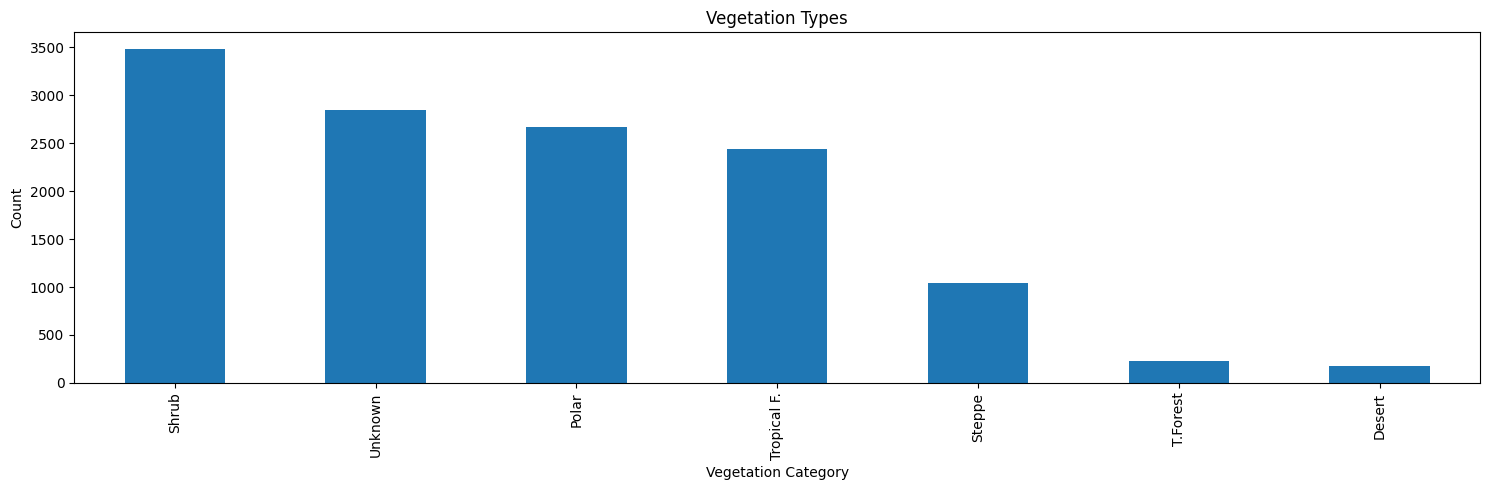

In [69]:
veg_map = {
    0: "Unknown",
    4: "T.Forest",
    9: "Steppe",
    12: "Shrub",
    14: "Desert",
    15: "Polar",
    16: "Tropical F."
}
# Filter only catastrophic fires
# Map vegetation labels
df['Vegetation_Label'] = df['Vegetation'].map(veg_map)
df_catastrophic = df[df['catastrophic'] == 1]


# Create a single subplot
fig, ax = plt.subplots(figsize=(15, 5))

# Plot bar chart
df_catastrophic["Vegetation_Label"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Vegetation Types")
ax.set_xlabel("Vegetation Category")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


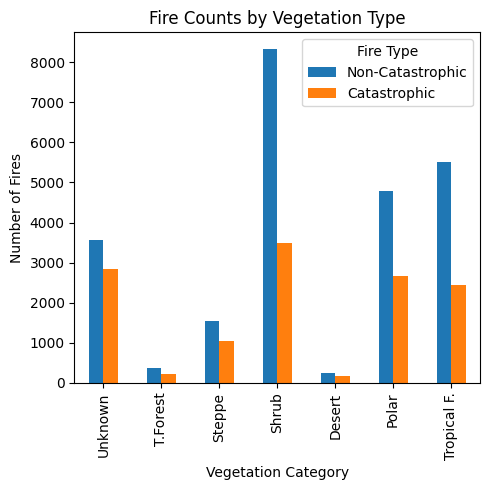

In [70]:
import matplotlib.pyplot as plt

# First, group by vegetation and target
fire_counts = df.groupby(['Vegetation_Label', 'catastrophic']).size().unstack(fill_value=0)

# Sort for consistent order
fire_counts = fire_counts.reindex(index=veg_map.values())

# Plot
ax = fire_counts.plot(kind='bar', figsize=(5, 5))
ax.set_title("Fire Counts by Vegetation Type")
ax.set_xlabel("Vegetation Category")
ax.set_ylabel("Number of Fires")
ax.legend(["Non-Catastrophic", "Catastrophic"], title="Fire Type")

plt.tight_layout()
plt.show()


In [ ]:
#durchschnittle fire size über vegetation, violin plot with firesize, destert..... 

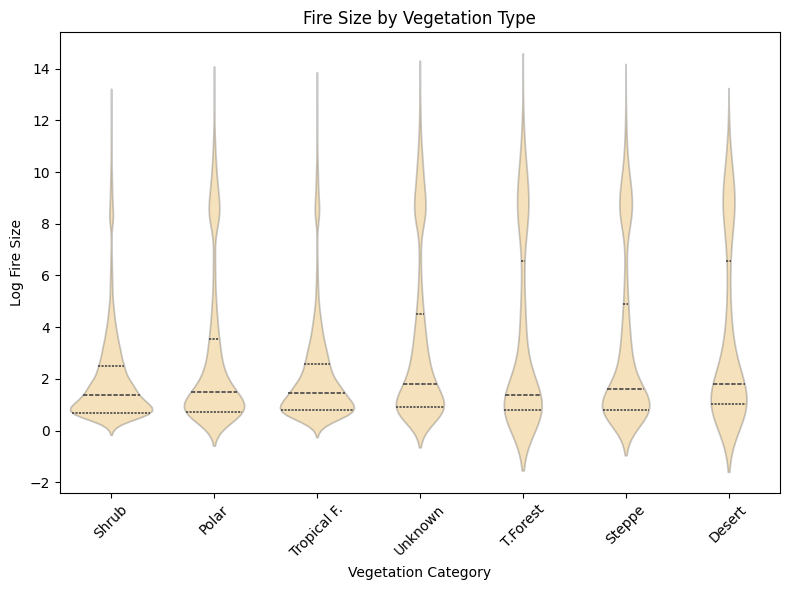

In [76]:
# Log-transform fire size
df['log_fire_size'] = np.log(df['fire_size'] + 1)

# Create the plot
plt.figure(figsize=(8, 6
                    ))
ax = sns.violinplot(x='Vegetation_Label', y='log_fire_size', data=df, inner='quartile', color='orange', alpha=0.3)

# Set axis labels and title using the Axes object
ax.set_xlabel("Vegetation Category")
ax.set_ylabel("Log Fire Size")
ax.set_title("Fire Size by Vegetation Type")

plt.xticks(rotation=45)  # Optional: tilt x-axis labels for readability
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

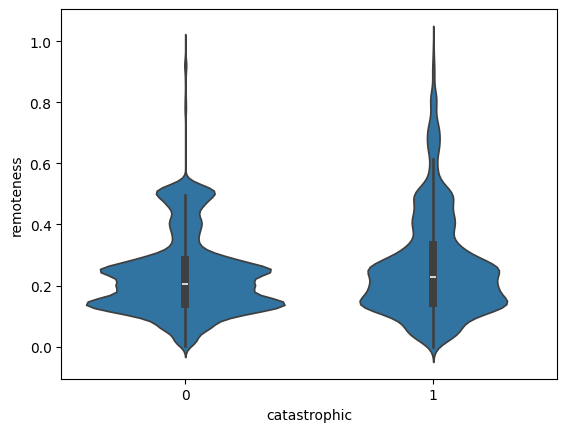

<Figure size 1000x600 with 0 Axes>

In [37]:
#sns.boxplot(x='catastrophic', y='remoteness', data=df)
sns.violinplot(x='catastrophic', y='remoteness', data=df)
plt.figure(figsize=(10, 6))

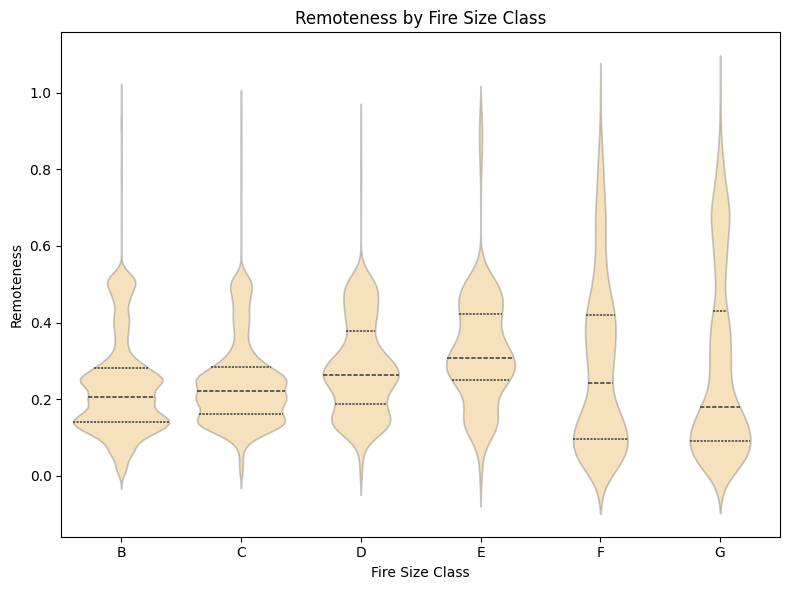

In [78]:
# Log-transform fire size
size_order = ['B', 'C', 'D', 'E', 'F', 'G']
# Create the plot
plt.figure(figsize=(8, 6
                    ))
ax = sns.violinplot(x='fire_size_class', y='remoteness', data=df, inner='quartile', color='orange', alpha=0.3, order=size_order)

# Set axis labels and title using the Axes object
ax.set_xlabel("Fire Size Class")
ax.set_ylabel("Remoteness")
ax.set_title("Remoteness by Fire Size Class")

plt.xticks(rotation=0)  # Optional: tilt x-axis labels for readability
plt.tight_layout()
plt.show()


<Axes: xlabel='fire_size_class', ylabel='count'>

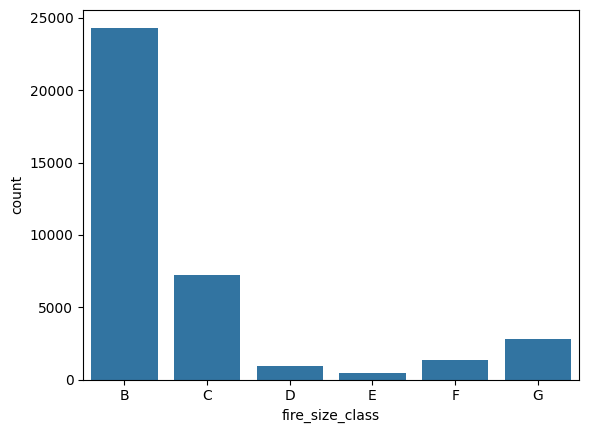

In [8]:
sns.countplot(x='fire_size_class', data=df, order=['B', 'C', 'D', 'E', 'F', 'G'])



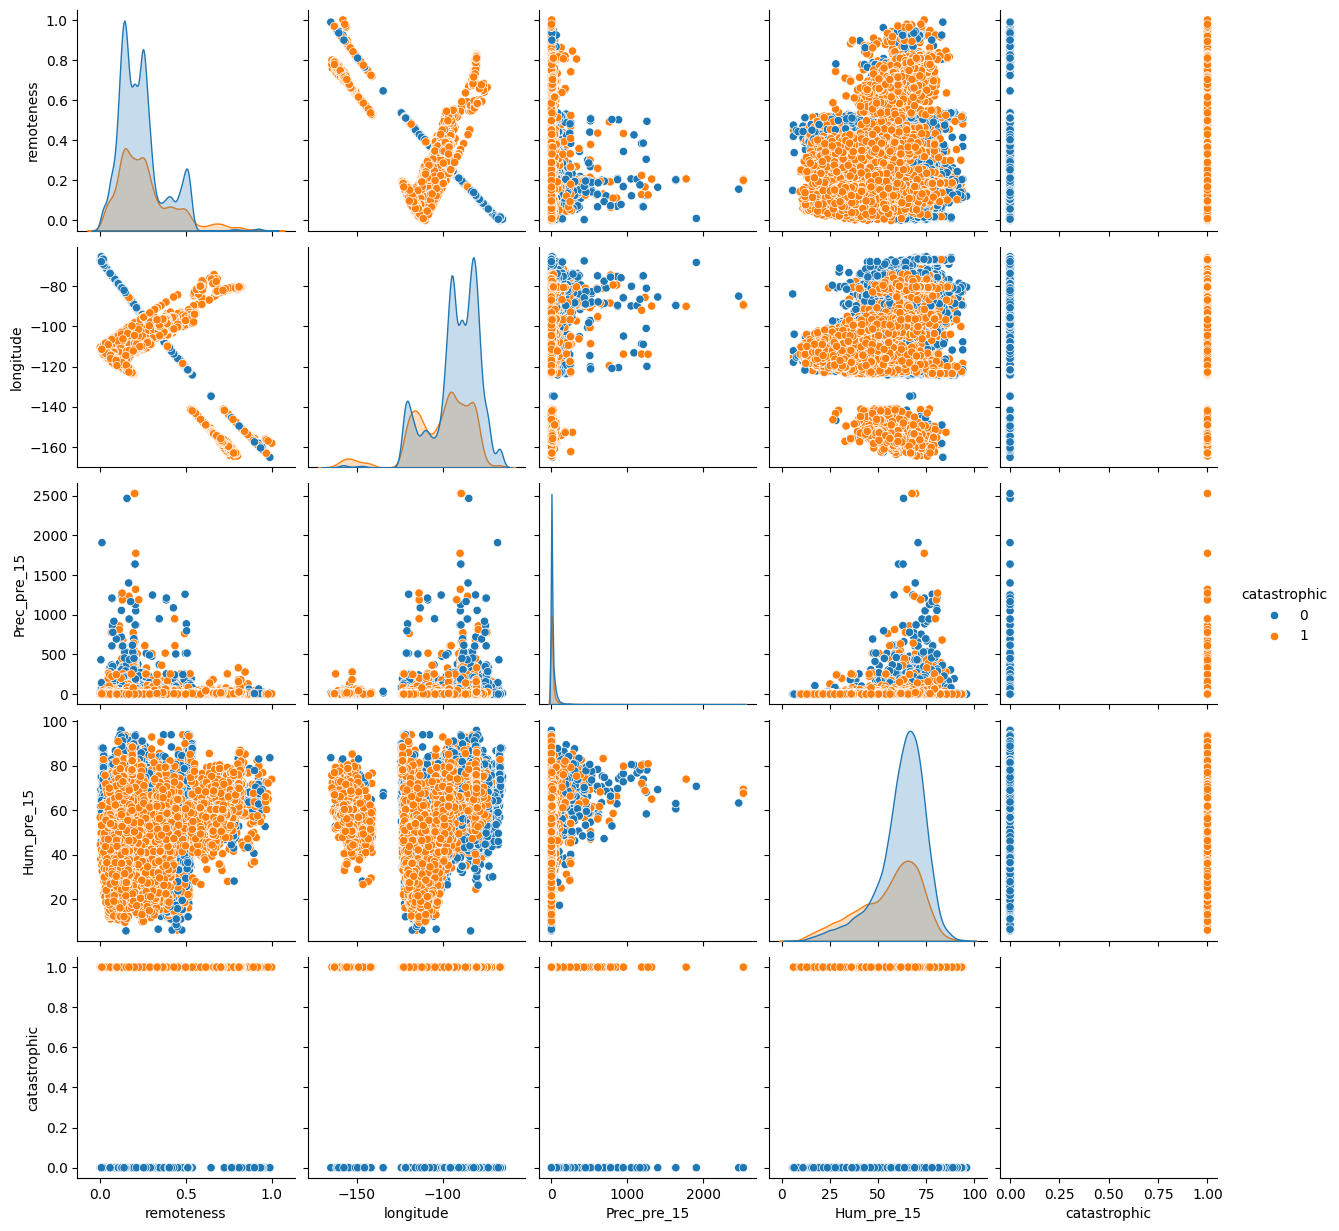

In [9]:
sns.pairplot(df, vars=['remoteness', 'longitude', 'Prec_pre_15','Hum_pre_15', 'catastrophic'], hue='catastrophic')


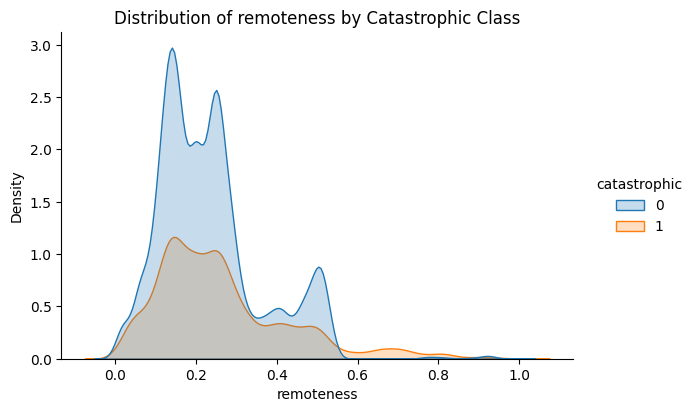

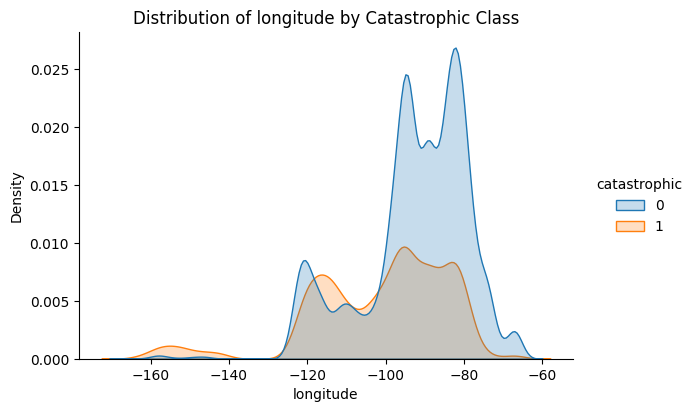

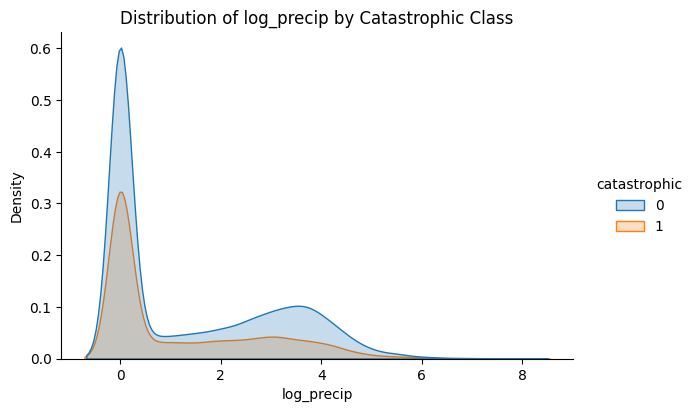

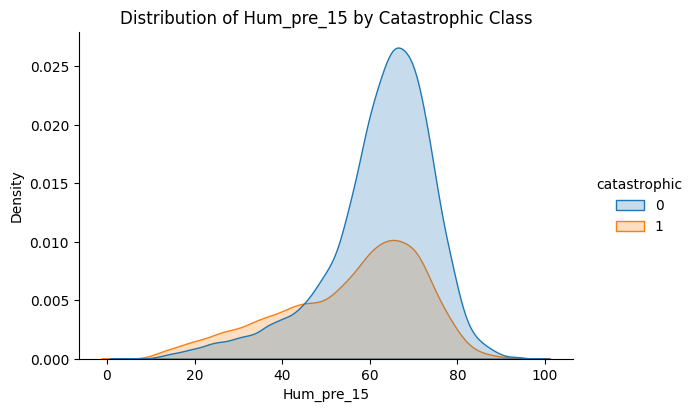

In [ ]:
df_transformed = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_transformed.csv')

df_transformed["fire_size"] = df["fire_size"]


In [11]:
df_transformed = df_transformed.drop(['index'], axis=1)
df_transformed.head()
df_transformed.info()
df_transformed.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37208 entries, 0 to 37207
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   latitude       37208 non-null  float64
 1   longitude      37208 non-null  float64
 2   Temp_pre_30    37208 non-null  float64
 3   Temp_pre_15    37208 non-null  float64
 4   Temp_pre_7     37208 non-null  float64
 5   Wind_pre_30    37208 non-null  float64
 6   Wind_pre_15    37208 non-null  float64
 7   Wind_pre_7     37208 non-null  float64
 8   Hum_pre_30     37208 non-null  float64
 9   Hum_pre_15     37208 non-null  float64
 10  Hum_pre_7      37208 non-null  float64
 11  Prec_pre_30    37208 non-null  float64
 12  Prec_pre_15    37208 non-null  float64
 13  Prec_pre_7     37208 non-null  float64
 14  remoteness     37208 non-null  float64
 15  catastrophic   37208 non-null  int64  
 16  month_sin      37208 non-null  float64
 17  month_cos      37208 non-null  float64
 18  Vegeta

,latitude,longitude,Temp_pre_30,Temp_pre_15,Temp_pre_7,Wind_pre_30,Wind_pre_15,Wind_pre_7,Hum_pre_30,Hum_pre_15,Hum_pre_7,Prec_pre_30,Prec_pre_15,Prec_pre_7,remoteness,catastrophic,month_sin,month_cos,fire_size
count,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,37208.000000,3.720800e+04,37208.000000,37208.000000
mean,36.475461,-95.643236,15.751560,16.252676,16.611517,3.171764,3.160079,3.136735,60.973810,60.040488,58.948962,39.482359,17.723995,7.361304,0.243298,0.346216,1.206883e-01,-0.172705,2211.284929
std,6.813169,15.877186,8.534825,8.417871,8.474401,1.177843,1.227829,1.313413,13.714828,14.182339,14.894387,134.725873,68.620599,37.778079,0.144646,0.475769,7.412336e-01,0.637343,14890.174705
min,17.958364,-165.116700,-16.078723,-37.000000,-48.200000,0.024922,0.017250,0.000000,5.625000,5.625000,5.625000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000e+00,-1.000000,0.510000
25%,32.377439,-103.445108,9.127583,9.715080,10.037742,2.350902,2.299691,2.221819,55.237437,53.461904,50.968015,0.000000,0.000000,0.000000,0.140661,0.000000,-5.000000e-01,-0.866025,1.100000
50%,34.699420,-93.185815,15.555082,16.070776,16.600000,3.072371,3.053857,3.010513,64.213802,63.044628,61.650099,3.400000,0.000000,0.000000,0.210863,0.000000,1.224647e-16,-0.500000,4.000000
75%,39.783547,-83.550410,23.115392,23.434649,23.793842,3.868383,3.877827,3.891667,70.334410,69.892706,69.469600,43.600000,15.125000,2.300000,0.291913,1.000000,8.660254e-01,0.500000,20.000000
max,69.047200,-65.417709,41.677820,51.567797,55.000000,29.800000,29.800000,29.800000,96.000000,96.000000,100.000000,13560.800000,2527.000000,1638.000000,1.000000,1.000000,1.000000e+00,1.000000,538049.000000


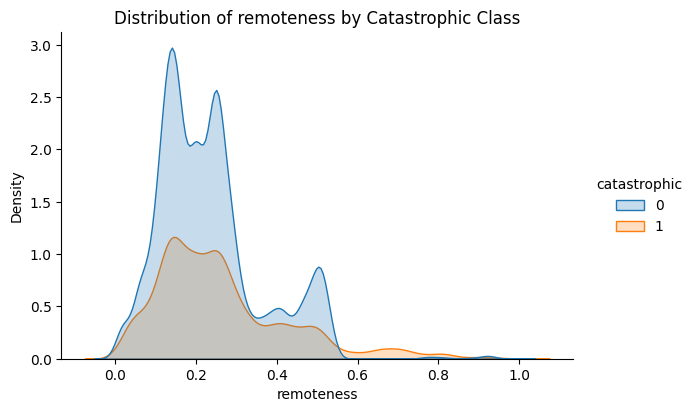

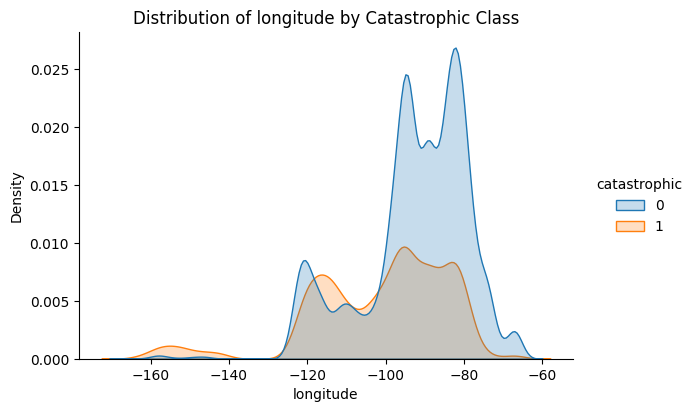

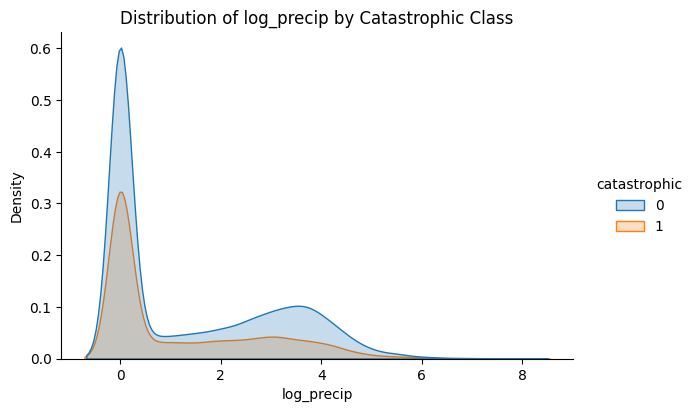

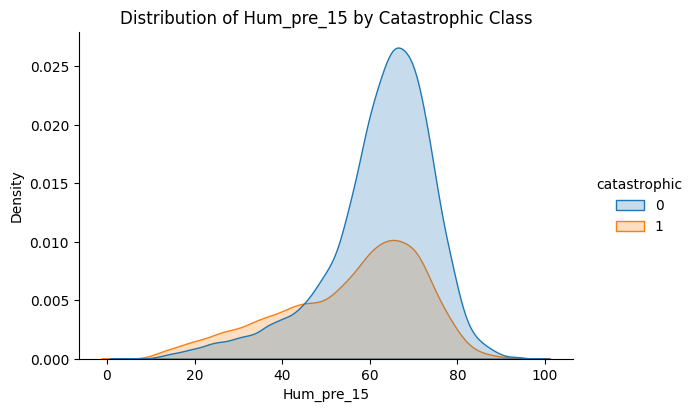

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

df_transformed['log_precip'] = np.log(df_transformed['Prec_pre_15'] + 1)

vars_to_plot = ['remoteness', 'longitude', 'log_precip', 'Hum_pre_15']

for var in vars_to_plot:
    sns.displot(data=df_transformed, x=var, hue='catastrophic', kind='kde', fill=True, height=4, aspect=1.5)
    plt.title(f"Distribution of {var} by Catastrophic Class")
    plt.show()


In [22]:
df_transformed['month_angle'] = np.arctan2(df_transformed['month_sin'], df_transformed['month_cos'])
df_transformed['month_angle'] = (df_transformed['month_angle'] + 2 * np.pi) % (2 * np.pi)


# Assign bin labels for visualization
df_transformed['month_bin'] = pd.cut(df_transformed['month_angle'], bins=12, labels=False)

# Group by month_bin to get count or mean fire size
month_stats = df_transformed.groupby('month_bin').agg(
    fire_count=('fire_size', 'count'),
    fire_mean=('fire_size', 'mean')
).reset_index()

# Convert bins back to center angles for plotting
month_stats['angle'] = (month_stats['month_bin'] + 0.5) * (2 * np.pi / 12)



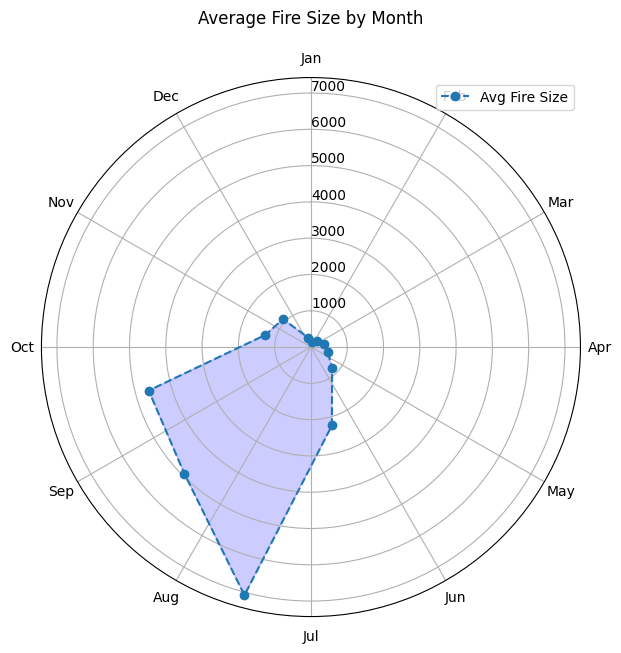

In [89]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
# Line or bar plot (choose one)
ax.plot(month_stats['angle'], month_stats['fire_mean'], marker='o', label="Avg Fire Size", linestyle='dashed')
ax.fill(month_stats['angle'], month_stats['fire_mean'], alpha=0.20, color='blue')
# ax.bar(month_stats['angle'], month_stats['fire_mean'], width=0.5, alpha=0.6)

# Format
ax.set_theta_direction(-1)       # Clockwise
ax.set_theta_offset(np.pi / 2)   # Start at top
ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

ax.set_title("Average Fire Size by Month", pad=20)
# Optional: adjust y-ticks
ax.set_rlabel_position(0)
plt.legend(loc='lower right', bbox_to_anchor=(1, 1))

plt.legend()
plt.show()


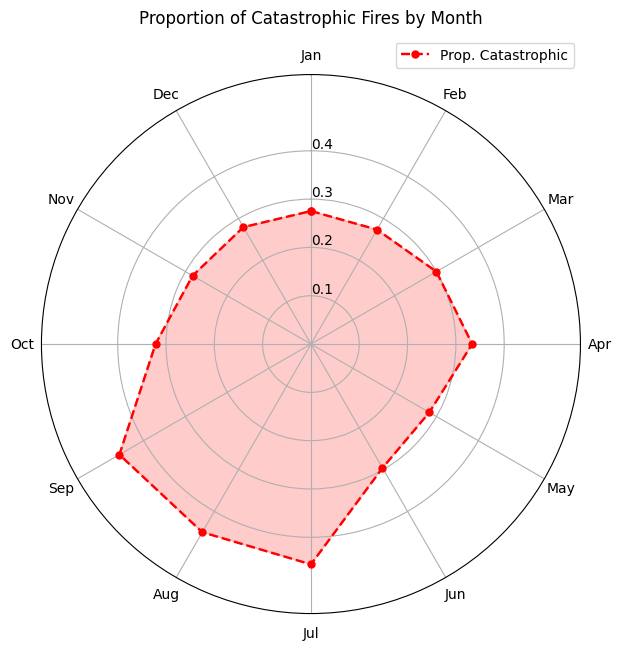

In [ ]:
month_stats_c = df_transformed.groupby('month_bin').agg(
    catastrophic_count=('catastrophic', 'count'),
    catastrophic_mean=('catastrophic', 'mean')
).reset_index()

# 12 monthly values (0 to 1) for proportion of catastrophic fires
categories = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
values = list(month_stats_c['catastrophic_mean'].head(12))  

# Data
labels = np.array(categories)
stats = np.array(values)

# Repeat first value to close the circular graph
stats = np.concatenate((stats, [stats[0]]))
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# Setup figure
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))


# Draw the outline
ax.plot(angles, stats, linewidth=1.75, linestyle='dashed', marker='o', markersize=5, color = 'red' ,  label='Prop. Catastrophic')
ax.fill(angles, stats, alpha=0.20, color = 'red')

# Fix axis
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Set labels
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

# Optional: adjust y-ticks
ax.set_rlabel_position(0)
ax.set_ylim(0, max(stats) + 0.1)
ax.set_yticks([0.1, 0.2, 0.3, 0.4])
ax.set_yticklabels(["0.1", "0.2", "0.3", "0.4"])

# Title + legend
plt.title("Proportion of Catastrophic Fires by Month", y=1.08)
plt.legend(loc='lower right', bbox_to_anchor=(1, 1))
plt.show()




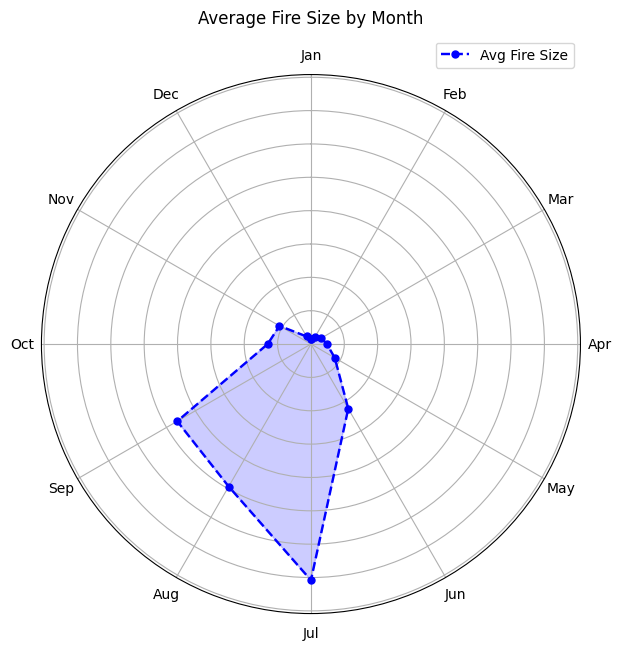

In [87]:
# Prepare data
categories = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
values = list(month_stats['fire_mean'].head(12))

# Repeat first value to close the radar chart
labels = np.array(categories)
stats = np.array(values)
stats = np.concatenate((stats, [stats[0]]))
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# Setup polar plot
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Line and fill
ax.plot(angles, stats, linewidth=1.75, linestyle='dashed', marker='o', markersize=5, color='blue', label='Avg Fire Size')
ax.fill(angles, stats, alpha=0.20, color='blue')

# Formatting
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_rlabel_position(0)

# Y-axis ticks (customize based on your value scale)
ax.set_yticklabels([])
ax.set_ylim(0, max(stats) + 1000)  # Add margin for visibility

# Title and legend
plt.title("Average Fire Size by Month", y=1.08)
plt.legend(loc='lower right', bbox_to_anchor=(1, 1))

plt.show()


In [88]:
plt.savefig(f'../reports/figures/name_of_plot_placeholder.png')

<Figure size 640x480 with 0 Axes>